# 실습 2: 문서 분석 — 폼(양식) & 표(Table) 추출
**소요시간: 50분** | 난이도: ⭐⭐⭐

## 학습 목표
1. `analyze_document`의 `FORMS` 기능으로 Key-Value 쌍을 추출합니다.
2. `TABLES` 기능으로 표 데이터를 파싱하고 pandas DataFrame으로 변환합니다.
3. Block 간 Relationships(관계)를 탐색하는 방법을 익힙니다.

## API 개요: analyze_document
```python
response = textract.analyze_document(
    Document={'Bytes': <바이트>},
    FeatureTypes=['FORMS', 'TABLES']  # 분석 기능 선택
)
```

### FORMS 분석 — Block 구조
```
KEY_VALUE_SET (EntityTypes=['KEY'])
├── Relationships[Type='CHILD']  → WORD Block들 (키 텍스트)
└── Relationships[Type='VALUE']  → KEY_VALUE_SET (EntityTypes=['VALUE'])
                                     └── Relationships[Type='CHILD'] → WORD Block들 (값 텍스트)
```

### TABLES 분석 — Block 구조
```
TABLE
└── Relationships[Type='CHILD'] → CELL Block들
                                     ├── RowIndex, ColumnIndex
                                     └── Relationships[Type='CHILD'] → WORD Block들
```


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54268 (\N{HANGUL SYLLABLE POM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt

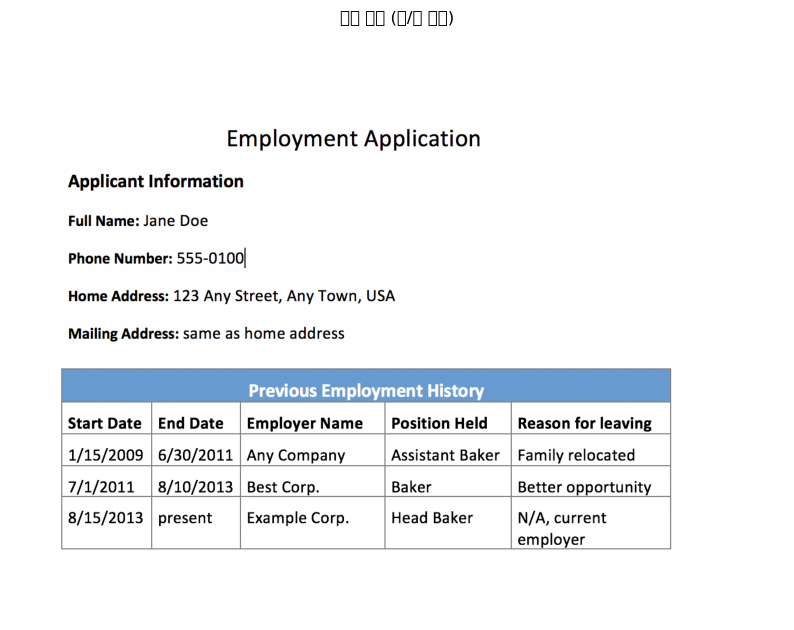

이미지 크기: (1362, 1038)


In [1]:
# ✅ [제공 코드]
import boto3, os, json
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import pandas as pd

textract = boto3.client('textract', region_name='ap-northeast-2')

IMAGE_DIR = './images/'
image_path = os.path.join(IMAGE_DIR, 'lab02_form.jpg')

def load_document_bytes(path):
    with open(path, 'rb') as f:
        return f.read()

doc_bytes = load_document_bytes(image_path)

img = Image.open(image_path)
plt.figure(figsize=(10, 12))
plt.imshow(img)
plt.axis('off')
plt.title('원본 문서 (폼/표 포함)')
plt.show()
print(f"이미지 크기: {img.size}")


## ✏️ TODO 1: analyze_document API 호출 (FORMS + TABLES)


In [ ]:
# ✏️ TODO 1: FORMS와 TABLES 기능을 모두 활성화하여 API를 호출하세요
response = textract.analyze_document(              # ← API 메서드명 (analyze_document)
    Document={'Bytes': doc_bytes},
    FeatureTypes=['FORMS', 'TABLES']          # ← 'FORMS', 'TABLES'
)

blocks = response['Blocks']
block_map = {b['Id']: b for b in blocks}

# BlockType 분포 확인
from collections import Counter
type_counts = Counter(b['BlockType'] for b in blocks)
print("BlockType 분포:")
for btype, cnt in sorted(type_counts.items()):
    print(f"  {btype:<25} {cnt:>5}개")


## ✏️ TODO 2: FORMS — Key-Value 쌍 추출

KEY_VALUE_SET 블록에서 키와 값 텍스트를 추출하는 함수를 완성하세요.


In [ ]:
# ✅ [제공 코드] Block에서 텍스트를 추출하는 헬퍼 함수
def get_text_from_block(block, block_map):
    """Block의 CHILD 관계에 있는 WORD들을 모아 텍스트 반환"""
    text = ''
    if 'Relationships' in block:
        for rel in block['Relationships']:
            if rel['Type'] == 'CHILD':
                for child_id in rel['Ids']:
                    child = block_map.get(child_id, {})
                    if child.get('BlockType') == 'WORD':
                        text += child.get('Text', '') + ' '
                    elif child.get('BlockType') == 'SELECTION_ELEMENT':
                        status = child.get('SelectionStatus', '')
                        text += ('[✓] ' if status == 'SELECTED' else '[ ] ')
    return text.strip()

print("✅ get_text_from_block() 함수 준비 완료")


In [ ]:
# ✏️ TODO 2: KEY 블록을 찾아 Value 블록과 연결하여 dict 형태로 반환하세요
def extract_forms(blocks, block_map):
    forms = {}
    
    # KEY 타입 블록만 필터링
    key_blocks = [
        b for b in blocks
        if b['BlockType'] == 'KEY_VALUE_SET'                           # ← 'KEY_VALUE_SET'
        and 'KEY' in b.get('EntityTypes', [])
    ]
    
    for key_block in key_blocks:
        key_text = get_text_from_block(key_block, block_map)
        value_text = ''
        
        # VALUE 블록 찾기: Relationships에서 Type='VALUE'인 관계
        for rel in key_block.get('Relationships', []):
            if rel['Type'] == 'VALUE':                          # ← 'Type', 'VALUE'
                for value_id in rel['Ids']:                  # ← 'Ids'
                    value_block = block_map.get(value_id)       # <- value_id
                    if value_block:
                        value_text = get_text_from_block(value_block, block_map)  # ← value_block
        
        if key_text:
            forms[key_text] = value_text
    
    return forms

# 함수 실행 및 결과 출력
form_data = extract_forms(blocks, block_map)
print(f"추출된 Key-Value 쌍: {len(form_data)}개")
print("\n폼 데이터:")
print("-" * 50)
for key, value in form_data.items():
    print(f"  {key:<30} : {value}")


## ✏️ TODO 3: TABLES — 표 데이터를 DataFrame으로 변환

TABLE 블록을 파싱하여 pandas DataFrame으로 변환하세요.


In [ ]:
# ✏️ TODO 3: TABLE 블록을 pandas DataFrame으로 변환하는 함수를 완성하세요
def extract_tables(blocks, block_map):
    tables = []
    table_blocks = [b for b in blocks if b['BlockType'] == 'TABLE']  # ← 'TABLE'
    
    for table_block in table_blocks:
        rows = {}
        
        # TABLE의 CHILD로 CELL 블록들이 있음
        for rel in table_block.get('Relationships', []):
            if rel['Type'] == 'CHILD':                        # ← 'Type'
                for cell_id in rel['Ids']:                   # ← 'Ids'
                    cell = block_map.get(cell_id)
                    if cell and cell['BlockType'] == 'CELL':
                        row_idx = cell['RowIndex']                 # ← 'RowIndex'
                        col_idx = cell['ColumnIndex']                 # ← 'ColumnIndex'
                        cell_text = get_text_from_block(cell, block_map)
                        
                        if row_idx not in rows:
                            rows[row_idx] = {}
                        rows[row_idx][col_idx] = cell_text
        
        # dict → DataFrame 변환
        if rows:
            max_row = max(rows.keys())
            max_col = max(max(r.keys()) for r in rows.values())
            data = []
            for r in range(1, max_row + 1):
                row_data = [rows.get(r, {}).get(c, '') for c in range(1, max_col + 1)]
                data.append(row_data)
            
            df = pd.DataFrame(data)
            # 첫 행을 헤더로 설정
            df.columns = df.iloc[0]
            df = df[1:].reset_index(drop=True)
            tables.append(df)
    
    return tables

table_list = extract_tables(blocks, block_map)
print(f"감지된 표: {len(table_list)}개")
for i, df in enumerate(table_list):
    print(f"\n표 #{i+1} ({df.shape[0]}행 x {df.shape[1]}열):")
    print(df.to_string())


## ✏️ TODO 4: TABLE과 KEY_VALUE 위치 시각화

TABLE은 빨간색, KEY_VALUE_SET(KEY)는 초록색으로 표시하세요.


In [ ]:
# ✏️ TODO 4: TABLE과 KEY_VALUE_SET 블록을 색상으로 구분하여 시각화하세요
img = Image.open(image_path).convert('RGB')
draw = ImageDraw.Draw(img)
w, h = img.size

color_map = {
    'TABLE': 'red',     # ← 'TABLE': 'red'
    'CELL': 'orange',     # ← 'CELL': 'orange'
    'KEY_VALUE_SET': 'green',     # ← 'KEY_VALUE_SET': 'green'
}

target_types = list(color_map.keys())

for block in blocks:
    btype = block['BlockType']
    if btype not in target_types:
        continue
    if 'Geometry' not in block:
        continue
    
    box = block['Geometry']['BoundingBox']
    left   = box['Left']  * w
    top    = box['Top']   * h
    right  = left + box['Width']  * w
    bottom = top  + box['Height'] * h
    color = color_map[btype]
    width = 3 if btype == 'TABLE' else 1
    draw.rectangle([left, top, right, bottom], outline=color, width=width)

plt.figure(figsize=(12, 14))
plt.imshow(img)
plt.axis('off')
plt.title('문서 분석 결과 (빨강=TABLE, 주황=CELL, 초록=KEY_VALUE)')
plt.show()


## ✏️ TODO 5: 추출 결과 저장

폼 데이터를 JSON으로, 표 데이터를 CSV로 저장하세요.


In [ ]:
# ✏️ TODO 5: 결과를 파일로 저장하세요
import json

# 폼 데이터 → JSON 저장
with open('form_result.json', 'w') as f:   # ← 'w'
    json.dump(form_data, f, ensure_ascii=False, indent=2)  # ← form_data
print("✅ form_result.json 저장 완료")

# 표 데이터 → CSV 저장
for i, df in enumerate(table_list):
    filename = f'table_{i+1}.csv'
    df.to_csv(filename, index=False, encoding='utf-8-sig')  # ← filename
    print(f"✅ {filename} 저장 완료 ({df.shape[0]}행)")


## 💡 심화 도전
1. 체크박스(SELECTION_ELEMENT) 필드를 감지하여 선택/미선택 여부를 출력해보세요.
2. 여러 페이지가 있는 PDF에서 페이지별로 표를 분리하여 저장해보세요.
3. 표에서 특정 열의 합계를 계산해보세요 (숫자가 있는 경우).
